## Pre-processing & Feature Engineering: E-Commerce Customer Behavior
**Role:** Data Engineer (Ibnu Dwiki Hermawan)

**Tujuan Notebook:**

1. Membersihkan data mentah dari *missing values* dan anomali transaksi.

2. Mengekstrak fitur RFM dan fitur tambahan (AvgSpending, UniqueProducts).

3. Menggunakan DBSCAN untuk menyaring *noise* / *outliers* sebelum masuk ke pemodelan K-Means.

In [131]:

# Import library esensial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from datetime import timedelta
import warnings
import os
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [132]:
# Memuat dataset (Pastikan path file disesuaikan dengan folder struktur repositori)
# Jika diletakkan di folder 'data/raw/':
file_path = '../data/raw/data.csv'
df = pd.read_csv(file_path, encoding="ISO-8859-1")

print(f"Dimensi data awal: {df.shape}")
df.head()

Dimensi data awal: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 1. Data Cleaning
Menghapus baris tanpa `CustomerID`, transaksi dengan kuantitas negatif/nol, dan transaksi yang dibatalkan (berawalan huruf 'C').

In [133]:
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean['InvoiceNo'] = df_clean['InvoiceNo'].astype(str)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Filter StockCode yang hanya merepresentasikan produk nyata (format >= 5 digit)
df_clean = df_clean[df_clean['StockCode'].str.contains(r'^\d{5}', na=False, regex=True)]
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Dimensi data setelah dibersihkan: {df_clean.shape}")

Dimensi data setelah dibersihkan: (404909, 9)


## 2. Feature Engineering (RFM + Fitur Tambahan)
Menghitung Recency, Frequency, dan Monetary, serta menambahkan `UniqueProducts` (keragaman produk) dan `AvgSpending` (rata-rata pengeluaran per transaksi).

In [134]:
# Ekstraksi indikator pembatalan
df_clean['IsCanceled'] = df_clean['InvoiceNo'].str.startswith('C')
cancellations = df_clean[df_clean['IsCanceled']].groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
cancellations.columns = ['CustomerID', 'CancelFrequency']

df_success = df_clean[(~df_clean['IsCanceled']) & (df_clean['Quantity'] > 0)].copy()
snapshot_date = df_success['InvoiceDate'].max() + timedelta(days=1)

# Agregasi dataset
customer_df = df_success.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum'),
    AvgSpending=('TotalPrice', 'mean'),
    UniqueProducts=('StockCode', 'nunique'),
    FirstPurchase=('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max')
).reset_index()

# Penggabungan dan perhitungan rasio
customer_df = customer_df.merge(cancellations, on='CustomerID', how='left')
customer_df['CancelFrequency'] = customer_df['CancelFrequency'].fillna(0)
customer_df['CustomerAgeMonths'] = ((customer_df['LastPurchase'] - customer_df['FirstPurchase']).dt.days / 30).clip(lower=1)
customer_df['AvgMonthlySpending'] = customer_df['Monetary'] / customer_df['CustomerAgeMonths']

# Pembersihan variabel redundan
customer_df = customer_df.drop(columns=['FirstPurchase', 'LastPurchase', 'CustomerAgeMonths'])
customer_df.set_index('CustomerID', inplace=True)

## 3. Scaling Data
Algoritma DBSCAN sangat sensitif terhadap skala jarak. Kita perlu menstandarisasi fitur menggunakan `StandardScaler`.

In [135]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_df)
scaled_df = pd.DataFrame(scaled_features, columns=customer_df.columns, index=customer_df.index)

scaled_df.head()

,Recency,Frequency,Monetary,AvgSpending,UniqueProducts,CancelFrequency,AvgMonthlySpending
CustomerID,,,,,,,
12346.0,2.329399,-0.425079,8.440020,52.515498,-0.708290,0.115084,47.293890
12347.0,-0.905391,0.360728,0.257031,-0.030140,0.487569,-0.392434,-0.052986
12348.0,-0.176565,-0.032176,-0.065551,-0.010017,-0.473808,-0.392434,-0.177069
12349.0,-0.735664,-0.425079,-0.063271,-0.032481,0.124121,-0.392434,0.626936
12350.0,2.169656,-0.425079,-0.193881,-0.033737,-0.532429,-0.392434,-0.089867


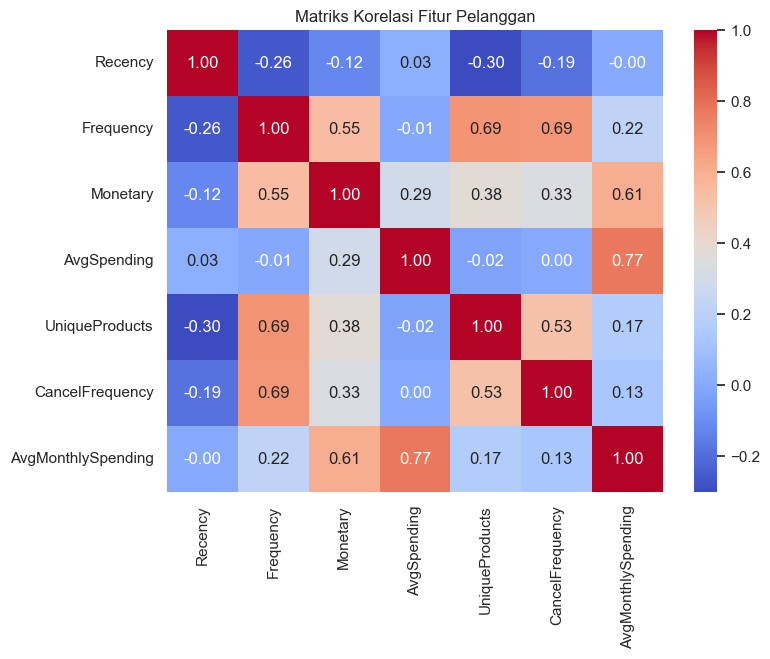

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat Heatmap Korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(customer_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriks Korelasi Fitur Pelanggan")
plt.show()

In [137]:
# Cek skewness sebelum Log dan Scaling
print("Skewness sebelum Log & Scaling:")
print(scaled_df.skew())

Skewness sebelum Log & Scaling:
Recency                1.243244
Frequency             11.947668
Monetary              19.566032
AvgSpending           46.465711
UniqueProducts         6.917622
CancelFrequency        9.182372
AvgMonthlySpending    30.745947
dtype: float64


In [138]:
skewed_features = customer_df.columns
for col in skewed_features:
    customer_df[col] = np.log1p(customer_df[col].clip(lower=0)) 

scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_df)
scaled_df = pd.DataFrame(scaled_features, columns=customer_df.columns, index=customer_df.index)

scaled_df.head()

,Recency,Frequency,Monetary,AvgSpending,UniqueProducts,CancelFrequency,AvgMonthlySpending
CustomerID,,,,,,,
12346.0,1.460681,-0.951088,3.716514,9.695196,-2.520718,0.605631,6.081845
12347.0,-2.038833,1.082400,1.422932,0.273403,0.966869,-0.633566,0.396147
12348.0,0.372170,0.392974,0.550228,1.194998,-0.404203,-0.633566,-0.487720
12349.0,-0.623675,-0.951088,0.561376,0.097815,0.654470,-0.633566,1.888469
12350.0,1.423259,-0.951088,-0.708125,-0.008474,-0.631777,-0.633566,0.201224


In [139]:
# Cek skewness setelah Log dan Scaling
print("Skewness setelah Log & Scaling:")
print(scaled_df.skew())

Skewness setelah Log & Scaling:
Recency              -0.378427
Frequency             1.214009
Monetary              0.362521
AvgSpending           1.600251
UniqueProducts       -0.244959
CancelFrequency       1.661183
AvgMonthlySpending    0.276151
dtype: float64


In [147]:
# === Grid Search untuk parameter optimal DBSCAN ===
print("Menjalankan grid search untuk parameter DBSCAN terbaik...")

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Definisikan rentang parameter yang akan diuji
eps_range = [0.8, 1.0, 1.2, 1.5, 1.8]
min_samples_range = [5, 10, 15, 20]

best_score = -1
best_eps = None
best_min_samples = None
best_labels = None

for eps in eps_range:
    for min_samples in min_samples_range:
        # Jalankan DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(scaled_df)
        
        # Hitung silhouette score hanya pada data yang bukan noise (label != -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters >= 2:
            sil_score = silhouette_score(
                scaled_df[labels != -1], 
                labels[labels != -1]
            )
            print(f"eps={eps}, min_samples={min_samples} -> clusters={n_clusters}, noise={sum(labels==-1)}, sil_score={sil_score:.3f}")
            
            if sil_score > best_score:
                best_score = sil_score
                best_eps = eps
                best_min_samples = min_samples
                best_labels = labels
        else:
            print(f"eps={eps}, min_samples={min_samples} -> clusters={n_clusters}, noise={sum(labels==-1)}, sil_score={sil_score:.3f}NaN (skip)")

print("\n=== Parameter Terbaik ===")
print(f"eps = {best_eps}, min_samples = {best_min_samples}")
print(f"Silhouette Score = {best_score:.3f}")
print(f"Jumlah cluster = {len(set(best_labels)) - (1 if -1 in best_labels else 0)}")
print(f"Jumlah noise = {sum(best_labels == -1)} dari {len(best_labels)} sampel")

# Gunakan parameter terbaik untuk DBSCAN akhir
dbscan_optimal = DBSCAN(eps=best_eps, min_samples=best_min_samples)
customer_df['Cluster_DBSCAN'] = dbscan_optimal.fit_predict(scaled_df)

# Lanjutkan kode Anda seperti sebelumnya...

Menjalankan grid search untuk parameter DBSCAN terbaik...
eps=0.8, min_samples=5 -> clusters=7, noise=569, sil_score=0.017
eps=0.8, min_samples=10 -> clusters=3, noise=892, sil_score=0.189
eps=0.8, min_samples=15 -> clusters=3, noise=1166, sil_score=0.175
eps=0.8, min_samples=20 -> clusters=2, noise=1453, sil_score=0.212
eps=1.0, min_samples=5 -> clusters=6, noise=275, sil_score=0.144
eps=1.0, min_samples=10 -> clusters=2, noise=402, sil_score=0.215
eps=1.0, min_samples=15 -> clusters=2, noise=501, sil_score=0.210
eps=1.0, min_samples=20 -> clusters=2, noise=578, sil_score=0.210
eps=1.2, min_samples=5 -> clusters=2, noise=149, sil_score=0.213
eps=1.2, min_samples=10 -> clusters=3, noise=211, sil_score=0.194
eps=1.2, min_samples=15 -> clusters=2, noise=262, sil_score=0.213
eps=1.2, min_samples=20 -> clusters=2, noise=307, sil_score=0.213
eps=1.5, min_samples=5 -> clusters=1, noise=53, sil_score=0.213NaN (skip)
eps=1.5, min_samples=10 -> clusters=1, noise=72, sil_score=0.213NaN (skip)
ep

## 4. DBSCAN untuk Filter Noise
Mendeteksi pelanggan yang memiliki pola transaksi anomali (*outliers*) agar tidak merusak klaster utama pada algoritma K-Means nanti.

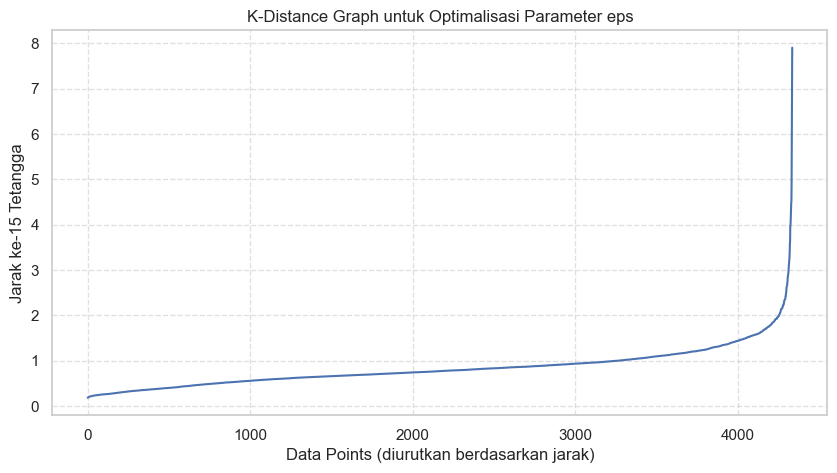

In [141]:
# Plot K-Distance untuk parameter DBSCAN
min_samples = 15
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(scaled_df)
distances, indices = neighbors_fit.kneighbors(scaled_df)
distances = np.sort(distances, axis=0)
distances = distances[:, min_samples-1]

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-Distance Graph untuk Optimalisasi Parameter eps')
plt.xlabel('Data Points (diurutkan berdasarkan jarak)')
plt.ylabel(f'Jarak ke-{min_samples} Tetangga')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [142]:

# Inisialisasi dan fit model DBSCAN
# (Parameter eps dan min_samples bisa di-tuning lebih lanjut)
dbscan = DBSCAN(eps=1.2, min_samples=5)
customer_df['Cluster_DBSCAN'] = dbscan.fit_predict(scaled_df)

# Memisahkan Inliers (bersih) dan Outliers (noise)
clean_data = customer_df[customer_df['Cluster_DBSCAN'] != -1].copy()
noise_data = customer_df[customer_df['Cluster_DBSCAN'] == -1].copy()

# Buang kolom penanda DBSCAN dari data bersih
clean_data = clean_data.drop(columns=['Cluster_DBSCAN'])
noise_data = noise_data.drop(columns=['Cluster_DBSCAN'])

print(f"Jumlah Pelanggan Normal (Inliers): {len(clean_data)}")
print(f"Jumlah Pelanggan Anomali (Outliers): {len(noise_data)}")

Jumlah Pelanggan Normal (Inliers): 4186
Jumlah Pelanggan Anomali (Outliers): 149


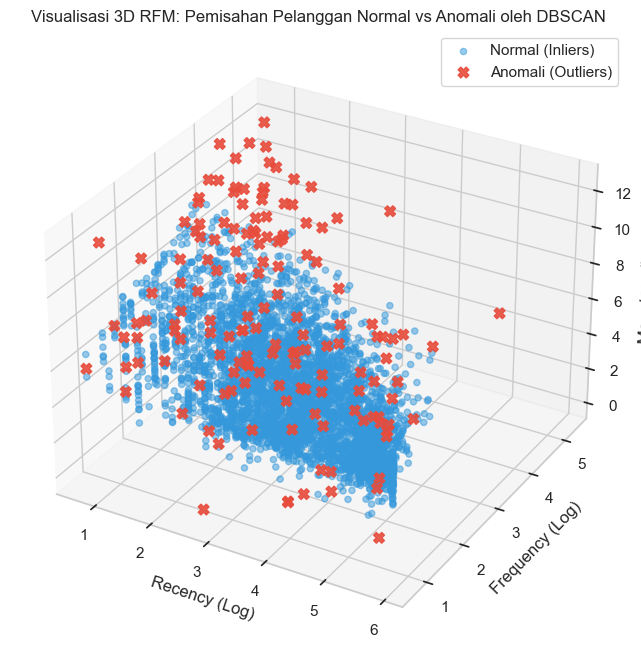

In [143]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Membuat figure 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Memisahkan data untuk pewarnaan plot (menggunakan customer_df yang masih ada kolom DBSCAN)
inliers = customer_df[customer_df['Cluster_DBSCAN'] != -1]
outliers = customer_df[customer_df['Cluster_DBSCAN'] == -1]

# Plot Pelanggan Normal (Inliers)
ax.scatter(inliers['Recency'], inliers['Frequency'], inliers['Monetary'], 
           c='#3498db', alpha=0.5, label='Normal (Inliers)', s=20)

# Plot Pelanggan Sultan/Anomali (Outliers)
ax.scatter(outliers['Recency'], outliers['Frequency'], outliers['Monetary'], 
           c='#e74c3c', alpha=0.9, label='Anomali (Outliers)', s=60, marker='X')

# Penyesuaian Label Sumbu (Telah di-Log)
ax.set_xlabel('Recency (Log)')
ax.set_ylabel('Frequency (Log)')
ax.set_zlabel('Monetary (Log)')
ax.set_title('Visualisasi 3D RFM: Pemisahan Pelanggan Normal vs Anomali oleh DBSCAN')

plt.legend()
plt.show()

Sedang memproses reduksi dimensi UMAP... (Mungkin memakan waktu beberapa detik)


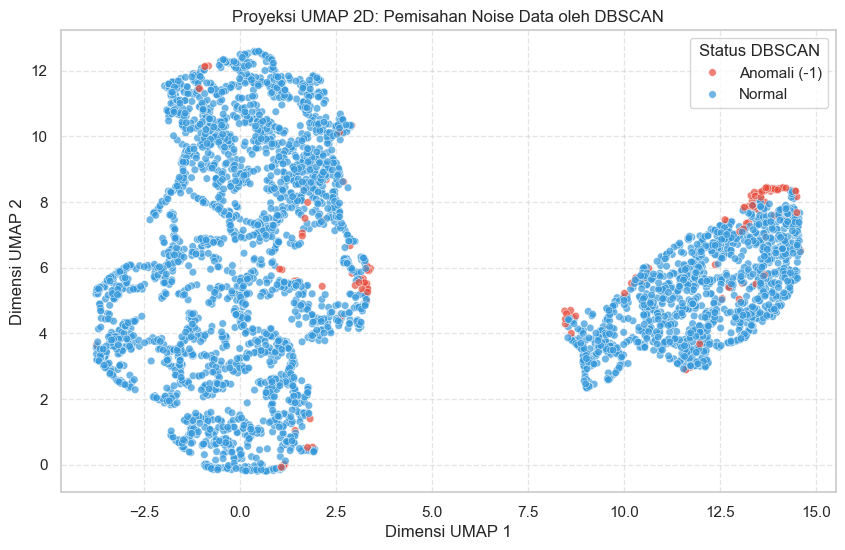

In [144]:
# Pastikan library umap sudah terinstall (pip install umap-learn)
import umap
import seaborn as sns

print("Sedang memproses reduksi dimensi UMAP... (Mungkin memakan waktu beberapa detik)")

# Mereduksi 7 fitur dari scaled_df menjadi 2 dimensi
umap_2d = umap.UMAP(n_components=2, random_state=42)
umap_proj = umap_2d.fit_transform(scaled_df)

# Memasukkan hasil proyeksi ke dalam DataFrame untuk di-plot
umap_df = pd.DataFrame(umap_proj, columns=['UMAP1', 'UMAP2'])
umap_df['Cluster_DBSCAN'] = customer_df['Cluster_DBSCAN'].values

# Mengubah label angka menjadi teks agar legenda lebih jelas
umap_df['Kategori'] = umap_df['Cluster_DBSCAN'].apply(lambda x: 'Anomali (-1)' if x == -1 else 'Normal')

# Membuat Scatter Plot 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=umap_df, 
    x='UMAP1', 
    y='UMAP2', 
    hue='Kategori', 
    palette={'Normal': '#3498db', 'Anomali (-1)': '#e74c3c'}, 
    alpha=0.7, 
    s=30
)

plt.title('Proyeksi UMAP 2D: Pemisahan Noise Data oleh DBSCAN')
plt.xlabel('Dimensi UMAP 1')
plt.ylabel('Dimensi UMAP 2')
plt.legend(title='Status DBSCAN')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

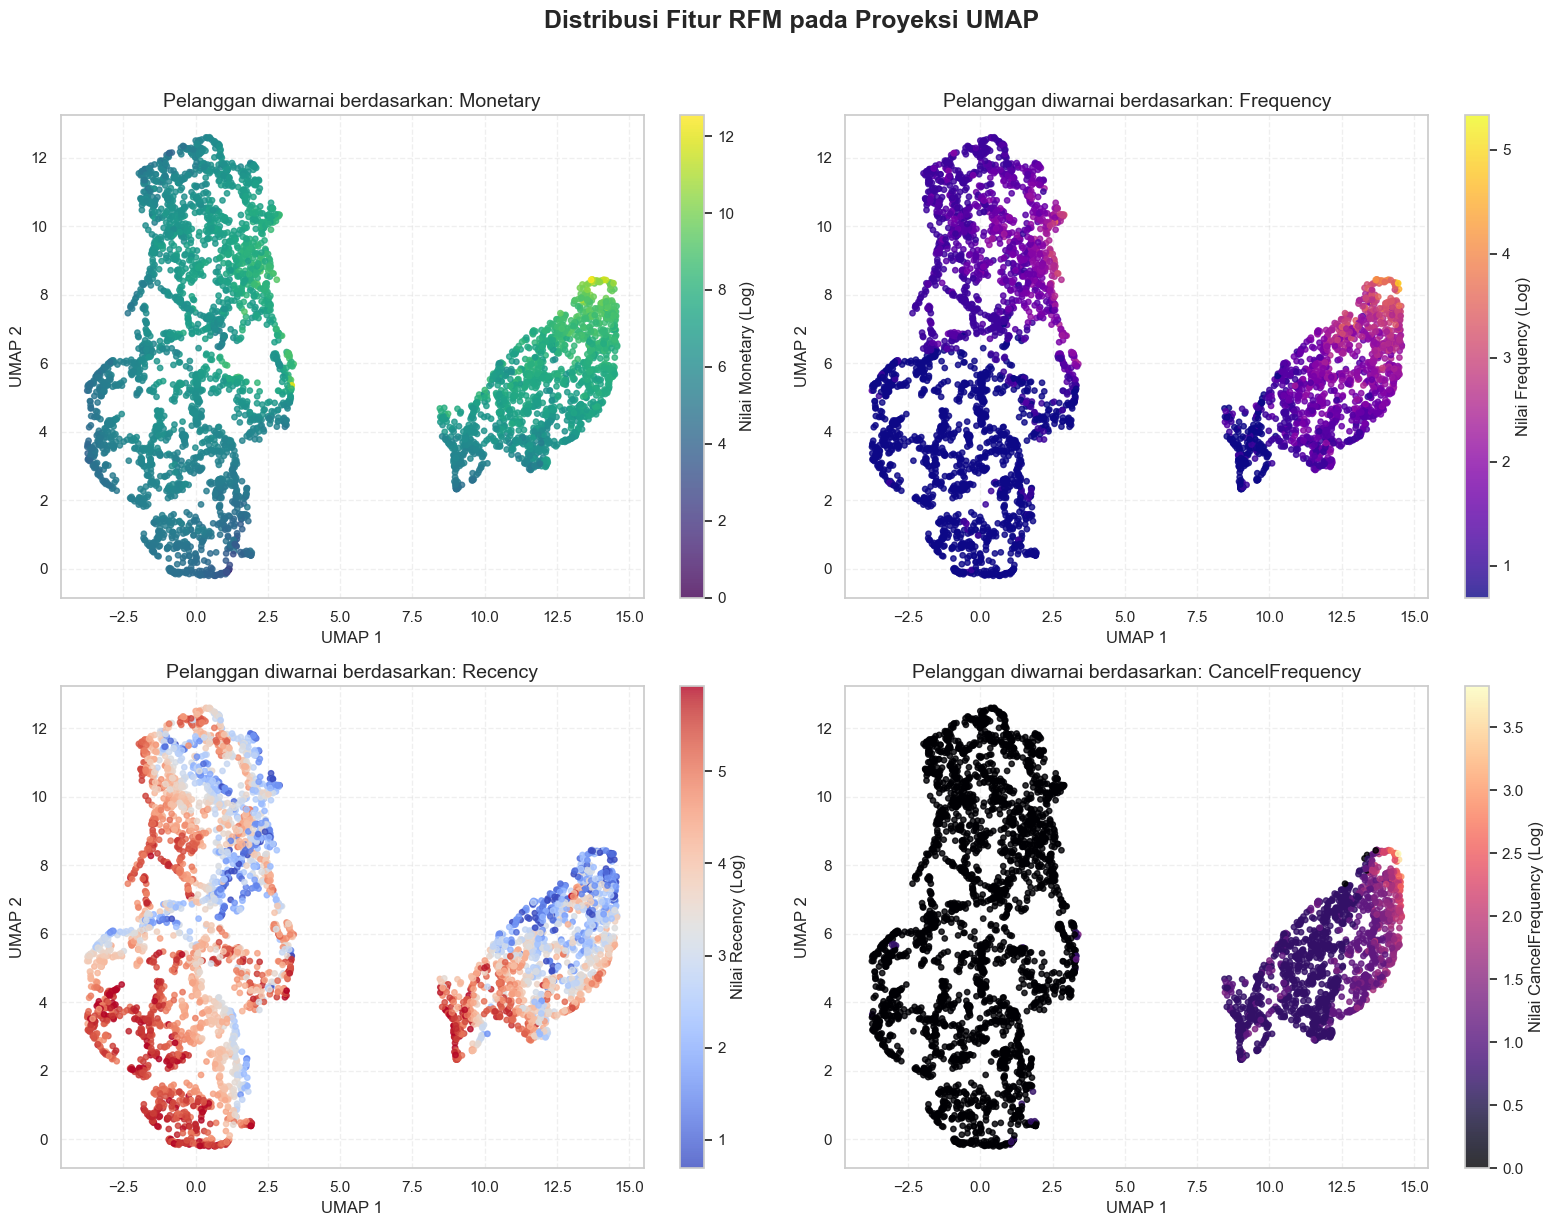

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan umap_df dari kode sebelumnya sudah ada
# Kita gabungkan nilai fitur dari customer_df ke dalam umap_df untuk pewarnaan
# Ingat: nilai di customer_df saat ini adalah nilai yang sudah di-Log Transformation
umap_feature_df = umap_df.copy()

# Memasukkan 4 fitur utama untuk dianalisis
fitur_utama = ['Monetary', 'Frequency', 'Recency', 'CancelFrequency']
for col in fitur_utama:
    umap_feature_df[col] = customer_df[col].values

# Membuat Kanvas Grid 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribusi Fitur RFM pada Proyeksi UMAP', fontsize=18, fontweight='bold', y=1.02)

# Menggambar 4 Plot dengan gradien warna berdasarkan nilai fitur
axes = axes.flatten()

# Pilihan warna gradien (colormap)
colormaps = ['viridis', 'plasma', 'coolwarm', 'magma']

for i, fitur in enumerate(fitur_utama):
    scatter = axes[i].scatter(
        umap_feature_df['UMAP1'], 
        umap_feature_df['UMAP2'], 
        c=umap_feature_df[fitur], # Warna ditentukan oleh nilai fitur
        cmap=colormaps[i],        # Tema gradien warna
        s=15,                     # Ukuran titik
        alpha=0.8
    )
    
    # Menambahkan Colorbar (skala warna) di setiap grafik
    cbar = plt.colorbar(scatter, ax=axes[i])
    cbar.set_label(f'Nilai {fitur} (Log)')
    
    axes[i].set_title(f'Pelanggan diwarnai berdasarkan: {fitur}', fontsize=14)
    axes[i].set_xlabel('UMAP 1')
    axes[i].set_ylabel('UMAP 2')
    axes[i].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [157]:
from sklearn.manifold import TSNE
import plotly.express as px
import pandas as pd

# 1. Menghitung t-SNE (Sama seperti sebelumnya)
print("Sedang menghitung t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=50, early_exaggeration=20.0, init='pca')
tsne_results = tsne.fit_transform(scaled_df)

# 2. Siapkan DataFrame untuk Plotly (Memasukkan data asli untuk Hover)
df_viz = pd.DataFrame({
    'Dimensi_1': tsne_results[:, 0],
    'Dimensi_2': tsne_results[:, 1],
    'Kategori': ['Outliers (Anomali)' if c == -1 else 'Inliers (Normal)' for c in customer_df['Cluster_DBSCAN']],
    'CustomerID': customer_df.index.astype(str), # Pastikan ID jadi teks
    'Monetary': customer_df['Monetary'],         # Kita panggil metrik asli
    'Frequency': customer_df['Frequency'],
    'Recency': customer_df['Recency']
})

# 3. Plotting Interaktif dengan Plotly Express
fig = px.scatter(
    df_viz, 
    x='Dimensi_1', 
    y='Dimensi_2', 
    color='Kategori',
    color_discrete_map={'Inliers (Normal)': '#4292c6', 'Outliers (Anomali)': '#ff0000'},
    hover_name='CustomerID', # Judul pop-up saat kursor diarahkan
    hover_data={'Dimensi_1': False, 'Dimensi_2': False, 'Kategori': False, # Sembunyikan koordinat t-SNE
                'Monetary': ':.2f', 'Frequency': True, 'Recency': True},   # Tampilkan metrik bisnis
    title='Interactive t-SNE: Pemisahan Pelanggan Normal vs Anomali'
)

# 4. Kustomisasi Ukuran Titik (Outliers dibuat lebih besar & mencolok)
fig.update_traces(marker=dict(size=6, opacity=0.6), selector=dict(name='Inliers (Normal)'))
fig.update_traces(marker=dict(size=6, line=dict(width=1, color='DarkRed'), opacity=1.0), selector=dict(name='Outliers (Anomali)'))

# 5. Kustomisasi Kanvas
fig.update_layout(
    plot_bgcolor='white',
    width=1000,
    height=700,
    title_font=dict(size=22),
    legend_title_text='Klasifikasi DBSCAN'
)

# Tampilkan Grafik Interaktif
fig.show()

Sedang menghitung t-SNE...


In [161]:
import pandas as pd
from IPython.display import display

# 1. Mengambil eksklusif data anomali (Label -1 dari DBSCAN)
anomali_df = customer_df[customer_df['Cluster_DBSCAN'] == -1].copy()

# 2. Membuat threshold pintar berdasarkan nilai tengah (median) dari kelompok anomali
batas_monetary = anomali_df['Monetary'].median()
batas_frequency = anomali_df['Frequency'].median()

# 3. Fungsi Rule-Based Profiling
def kategorikan_persona_anomali(row):
    # Kategori 1: Indikasi Fraud / Tukang Cancel
    # Jika pernah melakukan cancel sama sekali, langsung masuk radar ini
    if row['CancelFrequency'] > 0:
        return 'Indikasi Fraud / Bot (Tukang Cancel)'
        
    # Kategori 2: Reseller / Pemain Grosir (B2B)
    # Belanja sangat sering DAN nominalnya di atas rata-rata anomali
    elif row['Frequency'] > batas_frequency and row['Monetary'] > batas_monetary:
        return 'Reseller / Grosir (B2B)'
        
    # Kategori 3: Sultan Sekali Lewat (One-Time Big Spender)
    # Belanja jarang TAPI nominalnya luar biasa besar
    elif row['Frequency'] <= batas_frequency and row['Monetary'] > batas_monetary:
        return 'Sultan (One-Time Big Spender)'
        
    # Kategori 4: Anomali Minor
    else:
        return 'Anomali Minor (Nominal Kecil tapi Pola Aneh)'

# 4. Menerapkan fungsi ke DataFrame
anomali_df['Persona_Anomali'] = anomali_df.apply(kategorikan_persona_anomali, axis=1)

# 5. Mencetak Rangkuman Eksekutif untuk Presentasi
print("=== PROFILING PELANGGAN ANOMALI (OUTLIERS) ===")
print(anomali_df['Persona_Anomali'].value_counts())
print("\n" + "="*55 + "\n")

# Menampilkan bukti sampel data untuk tiap kategori (siap di-screenshot untuk slide)
kolom_penting = ['Monetary', 'Frequency', 'CancelFrequency', 'AvgSpending']

for persona in anomali_df['Persona_Anomali'].unique():
    print(f">> Contoh Pelanggan: {persona}")
    display(anomali_df[anomali_df['Persona_Anomali'] == persona][kolom_penting].head(3))
    print("-" * 55)

=== PROFILING PELANGGAN ANOMALI (OUTLIERS) ===
Persona_Anomali
Indikasi Fraud / Bot (Tukang Cancel)            273
Anomali Minor (Nominal Kecil tapi Pola Aneh)     78
Reseller / Grosir (B2B)                          32
Sultan (One-Time Big Spender)                    19
Name: count, dtype: int64


>> Contoh Pelanggan: Indikasi Fraud / Bot (Tukang Cancel)


,Monetary,Frequency,CancelFrequency,AvgSpending
CustomerID,,,,
12346.0,11.253955,0.693147,0.693147,11.253955
12409.0,9.312325,1.386294,1.609438,4.630683
12415.0,11.732587,3.044522,1.609438,5.166020


-------------------------------------------------------
>> Contoh Pelanggan: Sultan (One-Time Big Spender)


,Monetary,Frequency,CancelFrequency,AvgSpending
CustomerID,,,,
12357.0,8.733702,0.693147,0.0,3.879227
12378.0,8.296452,0.693147,0.0,2.960323
12435.0,8.965831,1.098612,0.0,5.386772


-------------------------------------------------------
>> Contoh Pelanggan: Anomali Minor (Nominal Kecil tapi Pola Aneh)


,Monetary,Frequency,CancelFrequency,AvgSpending
CustomerID,,,,
12358.0,6.834173,1.098612,0.0,4.018035
12464.0,6.864900,2.197225,0.0,3.795540
12603.0,6.420321,0.693147,0.0,6.420321


-------------------------------------------------------
>> Contoh Pelanggan: Reseller / Grosir (B2B)


,Monetary,Frequency,CancelFrequency,AvgSpending
CustomerID,,,,
12433.0,9.501282,2.079442,0.0,3.491870
12643.0,8.020481,1.945910,0.0,5.135681
12664.0,8.387740,2.302585,0.0,5.061663


-------------------------------------------------------


## 5. Export Data
Menyimpan dataset yang sudah bersih untuk diteruskan ke tahap K-Means.

In [146]:
# Ekspor ke folder processed
# clean_data.to_csv('../data/processed/clean_customer_features.csv')
# noise_data.to_csv('../data/processed/anomalous_customers.csv')

# print("Proses Data Engineering selesai. File CSV berhasil disimpan!")